# S&P 500 Options — SSVI Surface Calibration

This notebook calibrates the **parametric SSVI surface** on the forward-IV dataset
built in `01_build_forward_iv_dataset.ipynb`.

**Model**: Gatheral & Jacquier (2014) — 5-parameter surface:

$$w(k,T) = \frac{\theta(T)}{2}\left[1 + \rho\,\phi\,k + \sqrt{(\phi k + \rho)^2 + 1 - \rho^2}\right]$$

where $\theta(T) = e^\alpha T^\beta$, $\phi(\theta) = \eta\,\theta^{-\gamma}$,
and $w = \sigma_{IV}^2 T$ is total implied variance.

## A. Imports and setup

In [1]:
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')



In [ ]:
from pathlib import Path
import sys
import os
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

BASE = Path.cwd().resolve()
if BASE.name == "notebook":
    BASE = BASE.parent

# Step up to project root if src/ is not directly in cwd
PROJ_ROOT = BASE if (BASE / "src").exists() else BASE.parent

SRC_DIR   = PROJ_ROOT / "src"
OUTPUT_DIR = PROJ_ROOT / "output"
PLOT_DIR  = OUTPUT_DIR / "plots"
CACHE_DIR = OUTPUT_DIR / "cache"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from ssvi_surface import (
    prepare_ssvi_surface,
    calibrate_ssvi_surface,
    calibrate_all_dates,
    predict_ssvi_surface,
    print_ssvi_diagnostics,
    plot_ssvi_surface_fit,
    plot_ssvi_errors,
    plot_interactive_ssvi_surface,
    run_no_arbitrage_checks,
    run_no_arbitrage_checks_all,
    print_no_arbitrage_report,
    plot_no_arbitrage_conditions,
    plot_calendar_heatmap,
)

from ssvi_calibration import (
    filter_delta_butterfly_continuous,
    delta_min_tte,
    SSVI_DELTA_SHORT, SSVI_DELTA_LONG, SSVI_DELTA_DECAY,
    SSVI_MIN_LEFT_POINTS, SSVI_MIN_RIGHT_POINTS, SSVI_MIN_ATM_POINTS,
    SSVI_ATM_BAND, SSVI_FALLBACK_N,
)

print('Imports OK.')
print(f'SRC_DIR:    {SRC_DIR}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

## B. Load forward-IV dataset

In [ ]:
IV_PATH = OUTPUT_DIR / 'options_with_forward_iv_clean.csv'
if not IV_PATH.exists():
    raise FileNotFoundError(f'Run notebook 01 first to build: {IV_PATH}')

df = pd.read_csv(IV_PATH)
print(f'Dataset: {len(df):,} rows x {len(df.columns)} columns')
print(f'Dates: {df["Time Elapsed"].nunique()} unique')
print(f'Range: {df["Time Elapsed"].min():.0f} – {df["Time Elapsed"].max():.0f}')

# Sanity checks
req = ['forward_moneyness', 'implied_vol_forward', 'TTE', 'Liquidity Factor', 'OPEN INTEREST']
for c in req:
    status = 'OK' if c in df.columns else 'MISSING'
    print(f'  {c:<30} {status}')

Dataset: 1,818,064 rows x 19 columns
Dates: 2768 unique
Range: 0 – 4014
  forward_moneyness              OK
  implied_vol_forward            OK
  TTE                            OK
  Liquidity Factor               OK
  OPEN INTEREST                  OK


In [ ]:
# ── Delta butterfly filter parameters (configurable) ─────────────────────────
# delta_min(T) = delta_long + (delta_short - delta_long) * exp(-delta_decay * T)
#
#   T → 0 : delta_min → SSVI_DELTA_SHORT  (narrow band for short expiries)
#   T → ∞ : delta_min → SSVI_DELTA_LONG   (wide band for long expiries)

SSVI_DELTA_SHORT = 0.30   # abs_delta lower bound at T→0
SSVI_DELTA_LONG  = 0.05   # abs_delta lower bound at T→∞
SSVI_DELTA_DECAY = 3.0    # decay rate in years⁻¹

# ── Balance enforcement parameters (configurable) ────────────────────────────
SSVI_MIN_LEFT_POINTS  = 5     # min OTM-put  (k < 0)  observations after filter
SSVI_MIN_RIGHT_POINTS = 5     # min OTM-call (k > 0)  observations after filter
SSVI_MIN_ATM_POINTS   = 3     # min ATM (|k| ≤ atm_band) observations after filter
SSVI_ATM_BAND         = 0.03  # |k| ≤ this → ATM zone
SSVI_FALLBACK_N       = 10    # max fallback options added back per side

# Verify the delta boundary behaviour
T_check = np.array([0.0, 0.1, 0.5, 1.0, 2.0, 5.0])
d_check = delta_min_tte(T_check, SSVI_DELTA_SHORT, SSVI_DELTA_LONG, SSVI_DELTA_DECAY)
print('TTE (yrs) | delta_min | 1-delta_min  | kept abs_delta range')
for t, d in zip(T_check, d_check):
    print(f'  {t:5.2f}   |  {d:.4f}   |  {1-d:.4f}      | [{d:.4f}, {1-d:.4f}]')
print()
print(f'Balance enforcement:')
print(f'  Min OTM puts  (left,  k < -{SSVI_ATM_BAND}): {SSVI_MIN_LEFT_POINTS}')
print(f'  Min OTM calls (right, k >  {SSVI_ATM_BAND}): {SSVI_MIN_RIGHT_POINTS}')
print(f'  Min ATM       (|k| ≤ {SSVI_ATM_BAND}):         {SSVI_MIN_ATM_POINTS}')
print(f'  Fallback max per side:                 {SSVI_FALLBACK_N}')

In [ ]:
# ── Butterfly filter diagnostics (4-colour side-aware view) ──────────────────
# Applies the full side-aware filter to a sample date and shows:
#   left_put_otm  (salmon)  : OTM puts kept on left wing  (k < -atm_band)
#   right_call_otm (green)  : OTM calls kept on right wing (k >  atm_band)
#   atm           (orange)  : near-money options kept      (|k| ≤ atm_band)
#   discarded     (silver)  : removed by delta filter

from scipy.stats import norm as _norm

T_grid = np.linspace(0, 2.5, 400)
d_min  = delta_min_tte(T_grid, SSVI_DELTA_SHORT, SSVI_DELTA_LONG, SSVI_DELTA_DECAY)

sample_date = sorted(df['Time Elapsed'].unique())[len(df['Time Elapsed'].unique()) // 2]
df_day = df[df['Time Elapsed'] == sample_date].copy()

# Run the full side-aware filter (returns the kept slice with added columns)
df_all = df_day.copy()
k_col  = 'forward_moneyness'   if 'forward_moneyness'   in df_all.columns else 'Moneyness'
iv_col = 'implied_vol_forward' if 'implied_vol_forward' in df_all.columns else 'implied_vol'

# Compute abs_delta for ALL rows (needed to show discarded points too)
T_all = df_all['TTE'].to_numpy(float)
k_all = df_all[k_col].to_numpy(float)
sig_all = df_all[iv_col].fillna(0).to_numpy(float)
log_fk = -k_all
sqT    = np.sqrt(np.maximum(T_all, 1e-8))
sigs   = sig_all * sqT
d1_all = np.where(sigs > 1e-8, (log_fk + 0.5 * sig_all**2 * T_all) / sigs, np.nan)
cd_all = _norm.cdf(d1_all)
if 'OptionType' in df_all.columns:
    is_c_all  = df_all['OptionType'].to_numpy() == 1
    abs_d_all = np.where(is_c_all, cd_all, np.abs(cd_all - 1))
else:
    abs_d_all = np.where(k_all >= 0, cd_all, 1 - cd_all)

d_min_row = delta_min_tte(T_all, SSVI_DELTA_SHORT, SSVI_DELTA_LONG, SSVI_DELTA_DECAY)
raw_keep  = np.isfinite(abs_d_all) & (abs_d_all >= d_min_row) & (abs_d_all <= 1 - d_min_row)

# Run the full balanced filter to get the final kept set
sl_filtered = filter_delta_butterfly_continuous(
    df_all,
    delta_short=SSVI_DELTA_SHORT, delta_long=SSVI_DELTA_LONG, decay=SSVI_DELTA_DECAY,
    min_left_points=SSVI_MIN_LEFT_POINTS,
    min_right_points=SSVI_MIN_RIGHT_POINTS,
    min_atm_points=SSVI_MIN_ATM_POINTS,
    atm_band=SSVI_ATM_BAND,
    n_fallback=SSVI_FALLBACK_N,
)
attrs = sl_filtered.attrs

# Build masks on the kept slice for the 4 colour groups
k_kept   = sl_filtered[k_col].to_numpy(float)
T_kept   = sl_filtered['TTE'].to_numpy(float)
side_col = sl_filtered['smile_side'].to_numpy()
ad_kept  = sl_filtered['abs_delta'].to_numpy(float)

mask_left  = side_col == 'left_put_otm'
mask_right = side_col == 'right_call_otm'
mask_atm   = side_col == 'atm'

# Discarded: rows not in the filtered slice
idx_kept = set(sl_filtered.index if hasattr(sl_filtered, 'index') else range(len(sl_filtered)))
disc_mask = ~raw_keep & np.isfinite(abs_d_all)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: butterfly region shape ─────────────────────────────────────────────
ax = axes[0]
ax.plot(T_grid, d_min,     color='black', lw=2.0, label='delta_min(T)')
ax.plot(T_grid, 1 - d_min, color='black', lw=2.0, ls='--', label='1 − delta_min(T)')
ax.fill_between(T_grid, d_min, 1 - d_min, alpha=0.10, color='steelblue', label='kept region')
ax.axhline(0.5, color='gray', lw=0.7, ls=':')
ax.set_xlabel('TTE (years)')
ax.set_ylabel('abs_delta')
ax.set_title('Continuous butterfly filter region')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)

# ── Right: 4-colour scatter on actual data ────────────────────────────────────
ax2 = axes[1]

# 1. Discarded (light grey, background)
ax2.scatter(T_all[disc_mask], abs_d_all[disc_mask],
            s=3, alpha=0.20, c='#cccccc', label=f'Discarded ({disc_mask.sum():,})', zorder=1)
# 2. Left wing: OTM puts (salmon)
ax2.scatter(T_kept[mask_left], ad_kept[mask_left],
            s=5, alpha=0.55, c='#e8736c', label=f'OTM put left  ({mask_left.sum():,})', zorder=3)
# 3. Right wing: OTM calls (green)
ax2.scatter(T_kept[mask_right], ad_kept[mask_right],
            s=5, alpha=0.55, c='#4caf50', label=f'OTM call right ({mask_right.sum():,})', zorder=3)
# 4. ATM (orange)
ax2.scatter(T_kept[mask_atm], ad_kept[mask_atm],
            s=5, alpha=0.65, c='#f5a623', label=f'ATM           ({mask_atm.sum():,})', zorder=4)

T_curve = np.linspace(0, float(T_all.max()), 300)
d_curve = delta_min_tte(T_curve, SSVI_DELTA_SHORT, SSVI_DELTA_LONG, SSVI_DELTA_DECAY)
ax2.plot(T_curve, d_curve,     'k-',  lw=2.0, label='delta_min(T)', zorder=5)
ax2.plot(T_curve, 1 - d_curve, 'k--', lw=2.0, label='1 − delta_min(T)', zorder=5)

n_kept_total = int(mask_left.sum() + mask_right.sum() + mask_atm.sum())
ax2.set_xlabel('TTE (years)')
ax2.set_ylabel('abs_delta')
ax2.set_title(
    f'Side-aware butterfly filter — date {int(sample_date)}\n'
    f'kept {n_kept_total:,}  |  L={attrs["n_left_put_otm"]}  '
    f'ATM={attrs["n_atm"]}  R={attrs["n_right_call_otm"]}  '
    f'{"⚠ unbalanced" if attrs["flag_unbalanced_smile"] else "balanced"}'
)
ax2.legend(fontsize=8, markerscale=3, loc='upper right')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'ssvi_delta_butterfly_filter.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Date {int(sample_date)}: '
      f'kept {n_kept_total:,}  |  '
      f'left={attrs["n_left_put_otm"]}  atm={attrs["n_atm"]}  right={attrs["n_right_call_otm"]}  '
      f'discarded={disc_mask.sum():,}  '
      f'unbalanced={attrs["flag_unbalanced_smile"]}')

## C. Single-date SSVI calibration

We start with one date to inspect the fit quality before running all dates.

In [ ]:
# Choose a date with sufficient observations
date_counts = df.groupby('Time Elapsed').size()
test_date   = date_counts[date_counts >= 200].index[len(date_counts[date_counts >= 200])//2]

print(f'Calibrating SSVI for Time Elapsed = {test_date}')
print(f'Observations available: {date_counts[test_date]:,}')

result = calibrate_ssvi_surface(
    df, test_date,
    min_obs=100,
    min_iv=0.03, max_iv=2.0,
    min_tte=14/365,
    delta_short=SSVI_DELTA_SHORT,
    delta_long=SSVI_DELTA_LONG,
    delta_decay=SSVI_DELTA_DECAY,
    min_left_points=SSVI_MIN_LEFT_POINTS,
    min_right_points=SSVI_MIN_RIGHT_POINTS,
    min_atm_points=SSVI_MIN_ATM_POINTS,
    atm_band=SSVI_ATM_BAND,
    n_fallback=SSVI_FALLBACK_N,
    max_liquidity=0.30,
    use_weights=True,
    use_arbitrage_penalty=True,
)

print_ssvi_diagnostics(result)
print(f'Smile balance: left={result["n_left_put_otm"]}  atm={result["n_atm"]}  '
      f'right={result["n_right_call_otm"]}  unbalanced={result["flag_unbalanced_smile"]}')

In [ ]:
# Fit visualisation
sl    = prepare_ssvi_surface(
    df, test_date,
    min_obs=100, min_tte=14/365,
    delta_short=SSVI_DELTA_SHORT, delta_long=SSVI_DELTA_LONG, delta_decay=SSVI_DELTA_DECAY,
    min_left_points=SSVI_MIN_LEFT_POINTS, min_right_points=SSVI_MIN_RIGHT_POINTS,
    min_atm_points=SSVI_MIN_ATM_POINTS, atm_band=SSVI_ATM_BAND, n_fallback=SSVI_FALLBACK_N,
    max_liquidity=0.30,
)
pred  = predict_ssvi_surface(sl, result)

plot_ssvi_surface_fit(pred, result)
plot_ssvi_errors(pred)

In [ ]:
# Interactive 3D surface
# df_day_c = full single-date slice; sl = calibration subset from nb2-C2
try:
    df_day_c = df[df['Time Elapsed'] == test_date].copy()
    plot_interactive_ssvi_surface(
        df_all=df_day_c,
        sl_filtered=sl,   # output of prepare_ssvi_surface from nb2-C2
        result=result,
    )
except ImportError:
    print('plotly not installed — skipping 3D surface. Install with: pip install plotly')

## D. Calibrate all dates

Full calibration across all dates in the dataset (cached for re-runs).

In [ ]:
CACHE_SSVI = OUTPUT_DIR / 'ssvi_all_dates_clean_results.csv'
force_recompute = False

if CACHE_SSVI.exists() and not force_recompute:
    print(f'Loading cache: {CACHE_SSVI}')
    results_df = pd.read_csv(CACHE_SSVI)
else:
    print('Running SSVI calibration for all dates...')
    results_df = calibrate_all_dates(
        df,
        min_obs=100,
        use_weights=True,
        min_iv=0.03, max_iv=2.0,
        min_tte=14/365,
        delta_short=SSVI_DELTA_SHORT,
        delta_long=SSVI_DELTA_LONG,
        delta_decay=SSVI_DELTA_DECAY,
        min_left_points=SSVI_MIN_LEFT_POINTS,
        min_right_points=SSVI_MIN_RIGHT_POINTS,
        min_atm_points=SSVI_MIN_ATM_POINTS,
        atm_band=SSVI_ATM_BAND,
        n_fallback=SSVI_FALLBACK_N,
        max_liquidity=0.30,
        use_arbitrage_penalty=True,
        verbose=True,
    )
    results_df.to_csv(CACHE_SSVI, index=False)
    print(f'Saved: {CACHE_SSVI}')

In [ ]:
ok = results_df[results_df['success']]
n_tot = len(results_df)
n_ok  = len(ok)

print(f'Calibration success: {n_ok}/{n_tot} ({100*n_ok/n_tot:.1f}%)')
print()
print('Parameter medians (successful calibrations):')
for p in ['alpha', 'beta', 'rho', 'eta', 'gamma']:
    print(f'  {p:6s}: median={ok[p].median():.4f}   '
          f'[{ok[p].quantile(0.1):.4f}, {ok[p].quantile(0.9):.4f}]  (p10–p90)')
print()
print(f'Median RMSE_iv : {ok["rmse_iv"].median():.5f}')
print(f'Median n_obs   : {ok["n_obs"].median():.0f}')

Calibration success: 2666/2768 (96.3%)

Parameter medians (successful calibrations):
  alpha : median=-3.5532   [-3.9008, -2.8251]  (p10–p90)
  beta  : median=1.2172   [0.9678, 1.3493]  (p10–p90)
  rho   : median=-0.7493   [-0.8349, -0.6920]  (p10–p90)
  eta   : median=0.7317   [0.6098, 1.0690]  (p10–p90)
  gamma : median=0.5376   [0.4225, 0.6043]  (p10–p90)

Median RMSE_iv : 0.00806
Median n_obs   : 649


## E. No-arbitrage diagnostics

For the parametric SSVI surface, the **butterfly arbitrage-free conditions** are:

$$\text{cond1}(T) = \theta(T)\,\phi(T)\,(1+|\rho|) < 4$$
$$\text{cond2}(T) = \theta(T)\,\phi(T)^2\,(1+|\rho|) < 4$$

Cond2 is typically the binding one for SPX because short-maturity smiles are steep (large $\phi$).

In [ ]:
CACHE_NA = OUTPUT_DIR / 'no_arbitrage_clean_results.csv'

if CACHE_NA.exists() and not force_recompute:
    print(f'Loading no-arb cache: {CACHE_NA}')
    na_df = pd.read_csv(CACHE_NA)
else:
    print('Running no-arbitrage checks...')
    na_df = run_no_arbitrage_checks_all(results_df, n_k=100, n_T=200, verbose=True)
    na_df.to_csv(CACHE_NA, index=False)
    print(f'Saved: {CACHE_NA}')

print(f'\nNo-arbitrage summary ({len(na_df)} dates):')
print(f'  Butterfly-free : {na_df["butterfly_ok"].mean()*100:.1f}%')
print(f'  Calendar-free  : {na_df["calendar_ok"].mean()*100:.1f}%')
print(f'  Fully arb-free : {na_df["no_arbitrage"].mean()*100:.1f}%')

Running no-arbitrage checks...
  Checked 50/2666 dates …
  Checked 100/2666 dates …
  Checked 150/2666 dates …
  Checked 200/2666 dates …
  Checked 250/2666 dates …
  Checked 300/2666 dates …
  Checked 350/2666 dates …
  Checked 400/2666 dates …
  Checked 450/2666 dates …
  Checked 500/2666 dates …
  Checked 550/2666 dates …
  Checked 600/2666 dates …
  Checked 650/2666 dates …
  Checked 700/2666 dates …
  Checked 750/2666 dates …
  Checked 800/2666 dates …
  Checked 850/2666 dates …
  Checked 900/2666 dates …
  Checked 950/2666 dates …
  Checked 1000/2666 dates …
  Checked 1050/2666 dates …
  Checked 1100/2666 dates …
  Checked 1150/2666 dates …
  Checked 1200/2666 dates …
  Checked 1250/2666 dates …
  Checked 1300/2666 dates …
  Checked 1350/2666 dates …
  Checked 1400/2666 dates …
  Checked 1450/2666 dates …
  Checked 1500/2666 dates …
  Checked 1550/2666 dates …
  Checked 1600/2666 dates …
  Checked 1650/2666 dates …
  Checked 1700/2666 dates …
  Checked 1750/2666 dates …
  Checked

────────────────────────────────────────────────────────────
  No-Arbitrage Check  [PASS]
────────────────────────────────────────────────────────────
  Butterfly arbitrage : OK
    max cond1  θφ(1+|ρ|)  = 0.3997  (limit 4.0)
    max cond2  θφ²(1+|ρ|) = 1.6676  (limit 4.0)

  Calendar arbitrage  : OK
    violations: 0 (0.00% of grid)
────────────────────────────────────────────────────────────


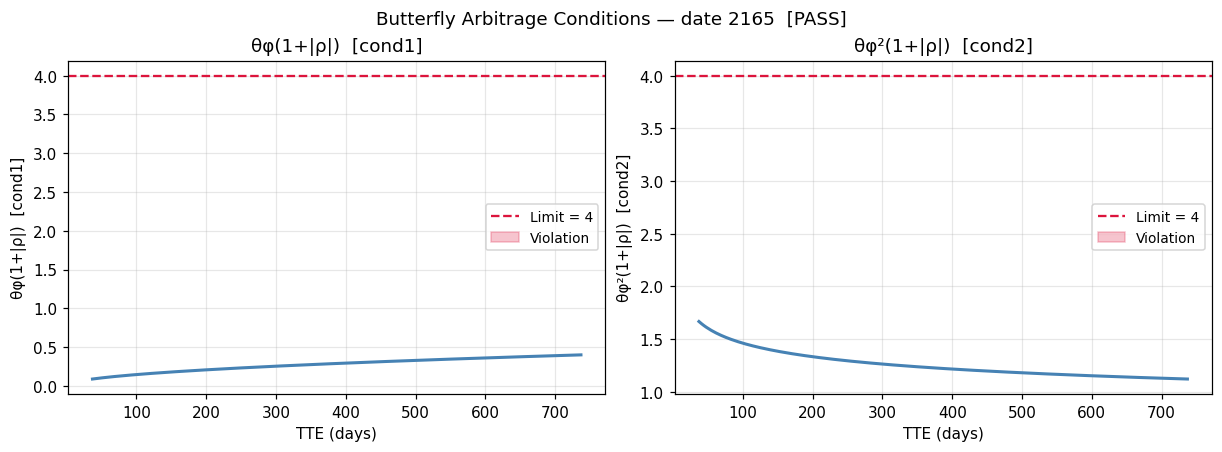

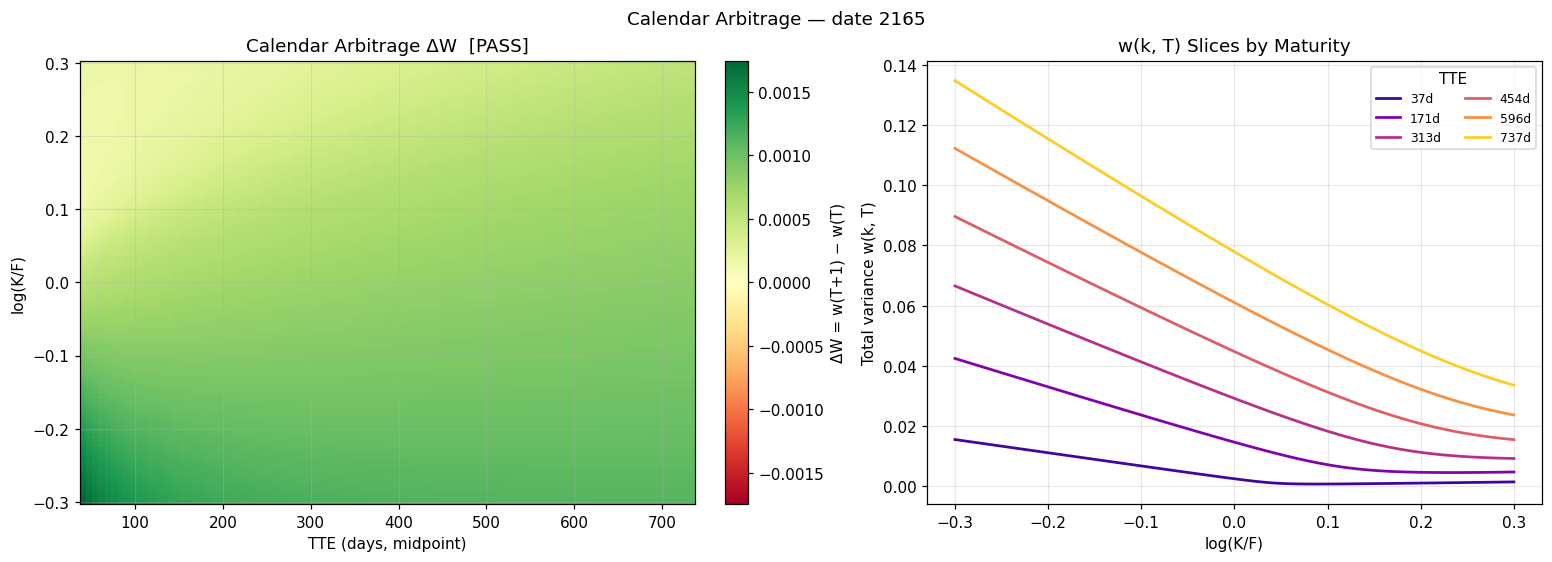

In [ ]:
# Single-date no-arb diagnostic
row_test = results_df[results_df['time_elapsed'] == test_date].iloc[0].to_dict()
row_test['tte_range'] = (row_test.get('tte_min', 14/365), row_test.get('tte_max', 3.0))

na_single = run_no_arbitrage_checks(row_test)
print_no_arbitrage_report(na_single)

plot_no_arbitrage_conditions(row_test)
plot_calendar_heatmap(row_test)

In [ ]:
# Worst cond2 dates
merged = results_df[results_df['success']].merge(na_df, on='time_elapsed')
worst  = merged.nlargest(10, 'max_cond2')[['time_elapsed','max_cond2','eta','rho','rmse_iv','n_obs']]
print('Top 10 dates by max cond2:')
print(worst.round(4).to_string(index=False))

Top 10 dates by max cond2:
 time_elapsed  max_cond2    eta     rho  rmse_iv  n_obs
         2954     4.0001 0.3351 -0.8962   0.0292    842
         2956     4.0000 0.5075 -0.7453   0.0092    914
         2955     4.0000 0.5517 -0.6967   0.0129    915
         2962     4.0000 0.5248 -0.7510   0.0177    962
         2976     4.0000 0.6565 -0.7034   0.0223    922
         2970     4.0000 0.5871 -0.7242   0.0197    941
         2969     4.0000 0.5830 -0.7119   0.0194    943
         2975     4.0000 0.6627 -0.6983   0.0236    920
         2977     4.0000 0.6177 -0.7432   0.0089    880
         2971     4.0000 0.6186 -0.7137   0.0192    939


**Why cond2 violations occur**: cond2 = $\theta\phi^2(1+|\rho|)$. High $\eta$ (steep smile)
and large $|\rho|$ together can push cond2 above 4, especially at short maturities where
$\theta$ is small but $\phi = \eta\theta^{-\gamma}$ is large. These are regimes of
elevated SPX vol-of-vol or jump-fear (e.g., VIX spikes).

Calendar arbitrage violations, when they occur, are numerically tiny ($\Delta W < 10^{-6}$)
and reflect the smooth nature of the parametric surface.

## F. Parameter time series

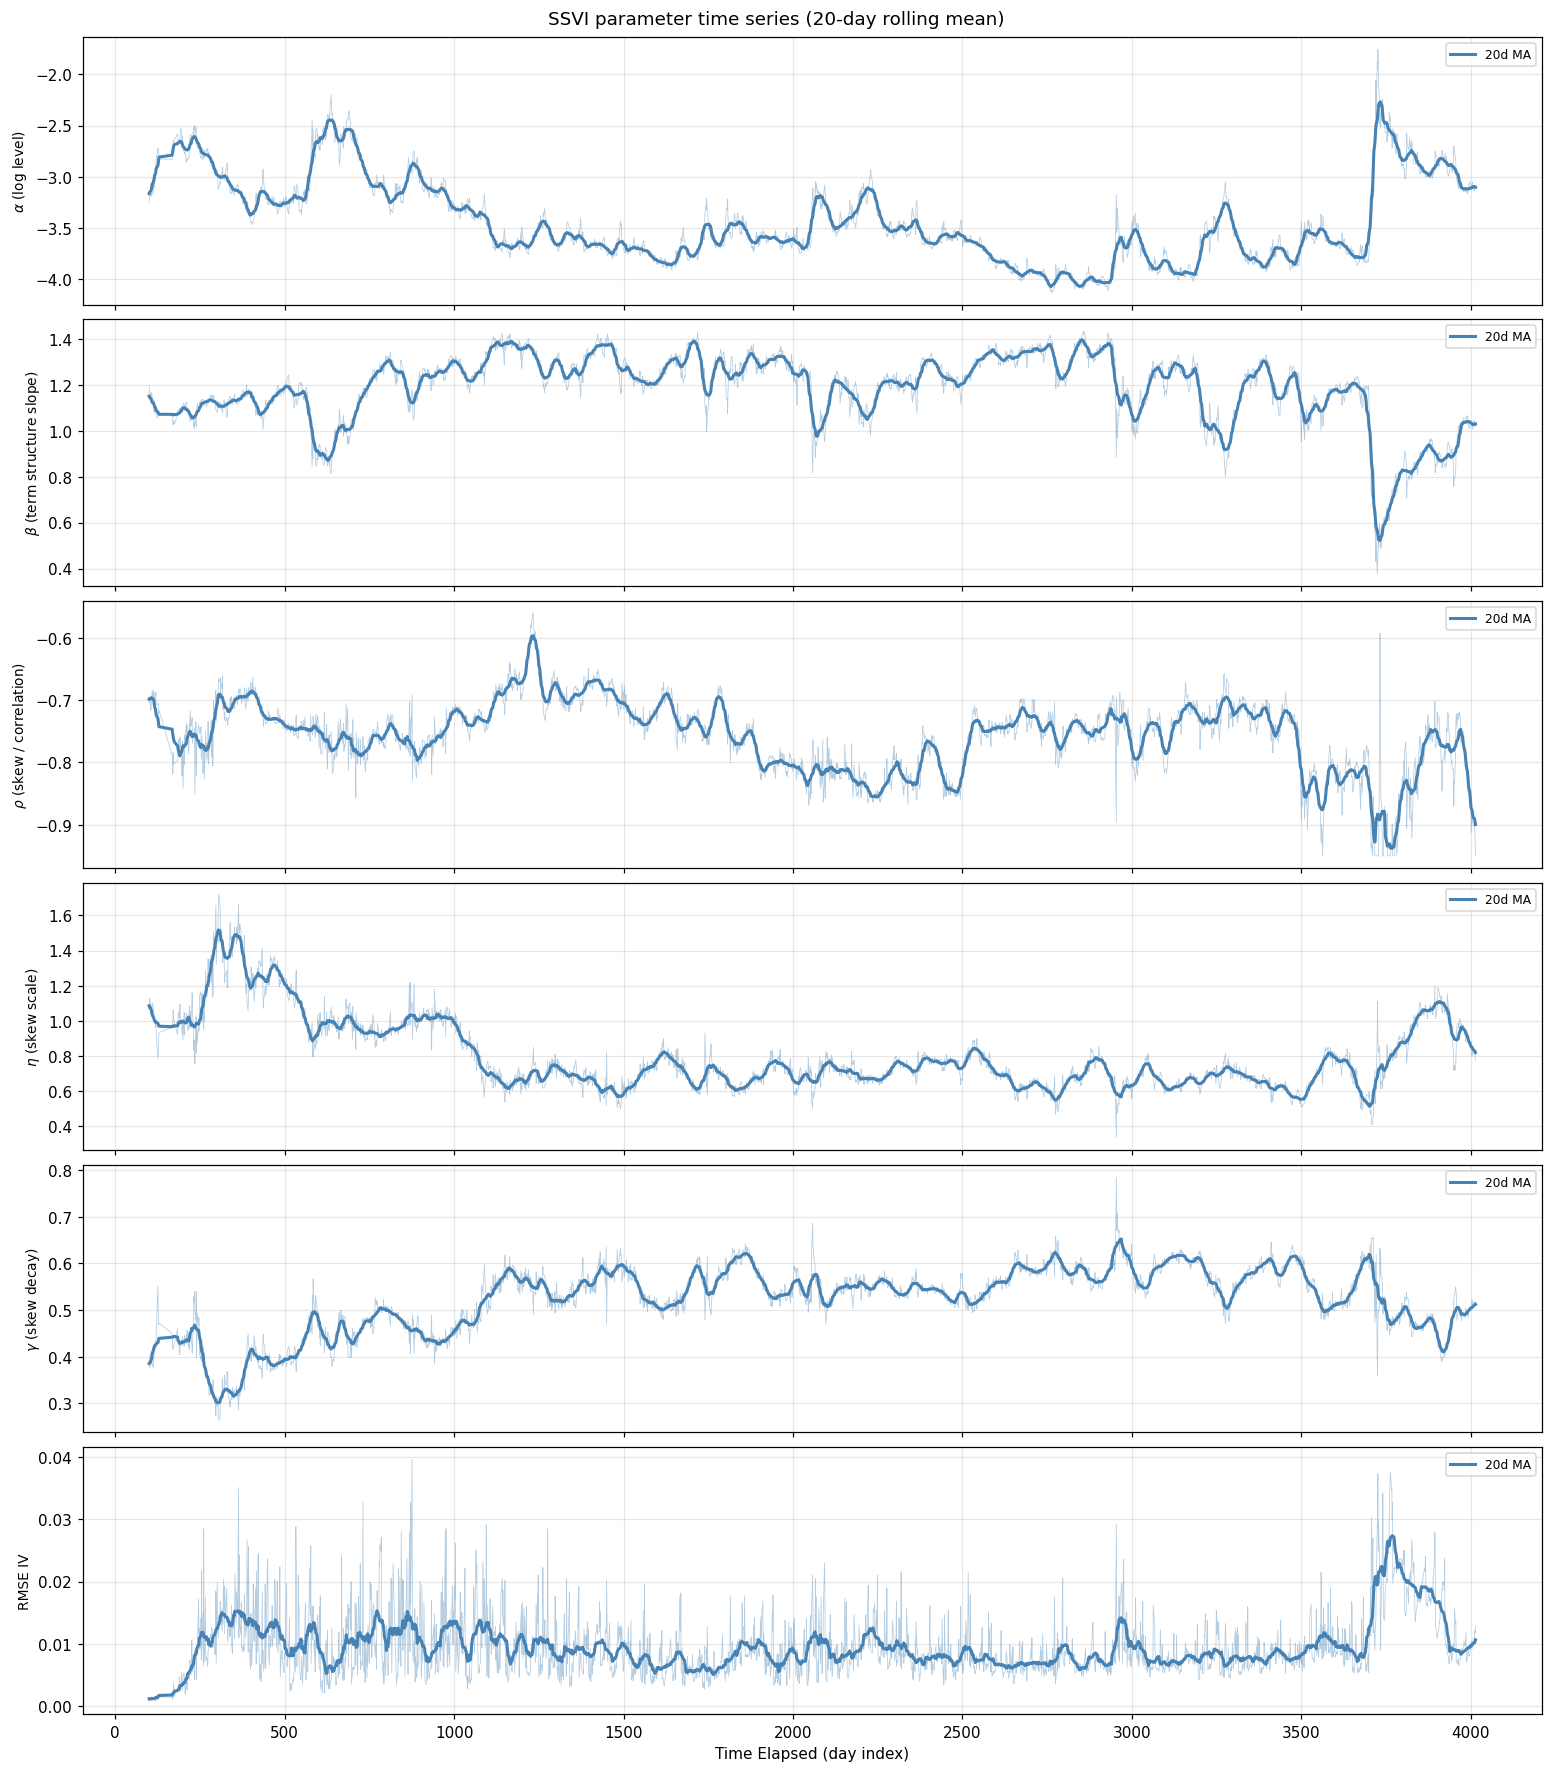

In [ ]:
ok = results_df[results_df['success']].sort_values('time_elapsed').reset_index(drop=True)

def rolling_ma(s, w=20):
    return s.rolling(w, min_periods=1, center=True).mean()

params = ['alpha', 'beta', 'rho', 'eta', 'gamma', 'rmse_iv']
labels = [
    r'$\alpha$ (log level)',
    r'$\beta$ (term structure slope)',
    r'$\rho$ (skew / correlation)',
    r'$\eta$ (skew scale)',
    r'$\gamma$ (skew decay)',
    'RMSE IV',
]

fig, axes = plt.subplots(6, 1, figsize=(14, 16), sharex=True, constrained_layout=True)
fig.suptitle('SSVI parameter time series (20-day rolling mean)', fontsize=12)

for ax, col, lab in zip(axes, params, labels):
    y = ok[col].values
    ax.plot(ok['time_elapsed'], y, lw=0.5, alpha=0.4, color='steelblue')
    ax.plot(ok['time_elapsed'], rolling_ma(ok[col]), lw=2.0, color='steelblue', label='20d MA')
    ax.set_ylabel(lab, fontsize=9)
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Time Elapsed (day index)')
plt.show()

## G. Economic interpretation

### Parameter meanings

| Parameter | Formula | Interpretation |
|-----------|---------|----------------|
| $\alpha$ | $e^\alpha$ = ATM total-var level | Baseline implied variance level |
| $\beta$ | $\theta\sim T^\beta$ | Term-structure slope: $\beta<1$ = concave, common for SPX |
| $\rho$ | skew direction | Negative = left-skewed smile (crash fear). SPX typically $\rho\in[-0.8,-0.3]$ |
| $\eta$ | $\phi=\eta\theta^{-\gamma}$ | Smile steepness: higher $\eta$ = steeper wings |
| $\gamma$ | skew decay | How fast smile flattens with maturity: $\gamma\approx 0.5$ is typical |

### Arbitrage conditions

- **cond2 violations** occur when $\eta$ is large and $|\rho|$ is high — these are short-maturity
  regimes with very steep smiles (e.g., VIX spikes). Economically, the market is pricing
  extreme jump risk that the parametric SSVI cannot fully accommodate without violating
  the no-butterfly condition.

- **Calendar spread violations** are numerically negligible in the parametric SSVI
  because $\theta(T)=e^\alpha T^\beta$ is monotonically increasing in $T$ for $\beta>0$,
  which implies $w(k,T)$ is non-decreasing in $T$ for most parameter combinations.

### SSVI vs Heston

SSVI fits a **static** implied-vol surface per date — it has no dynamics and cannot price
path-dependent derivatives. Its advantage is speed (< 100 ms per date) and parsimony
(5 interpretable parameters). Heston provides stochastic-vol paths but requires
discount-factor inputs and is 1000× slower per calibration.

## H. Stress / violation analysis

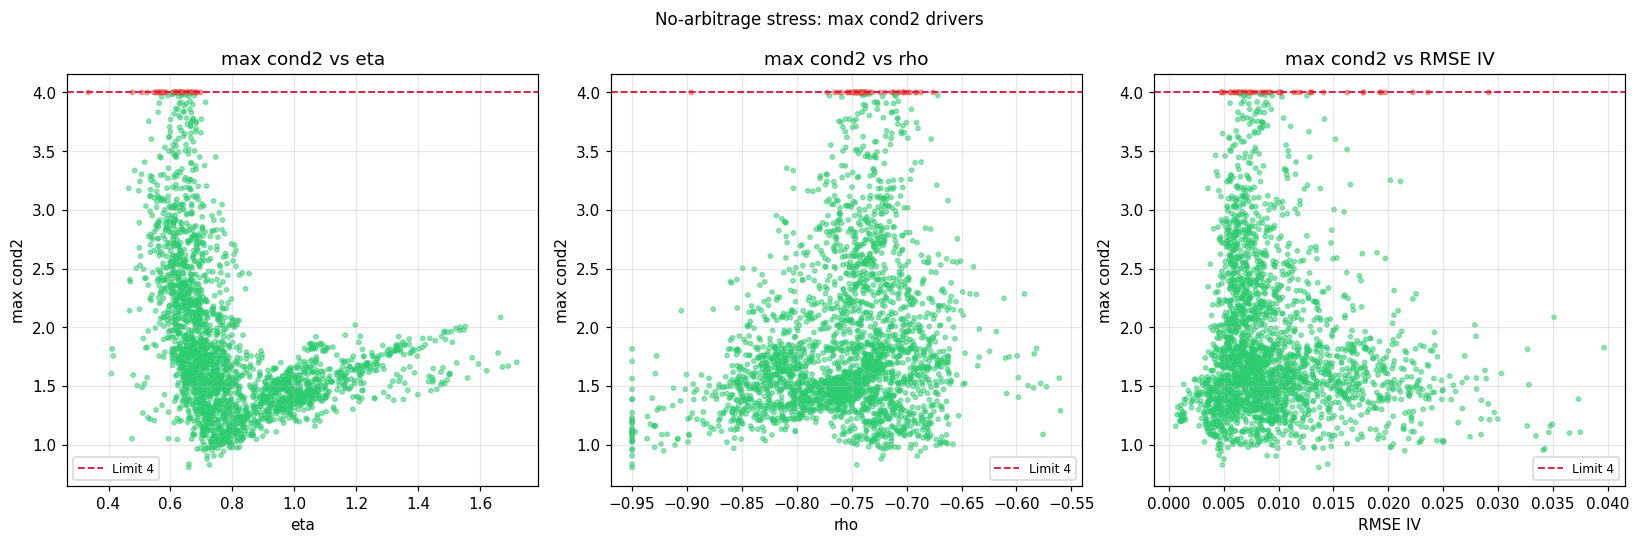

Butterfly violations: 51 / 2666 dates
Correlation  eta – max_cond2 : -0.404
Correlation |rho|– max_cond2 : -0.224


In [ ]:
# Merge calibration results with no-arb checks
merged = ok.merge(na_df, on='time_elapsed', how='inner')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('No-arbitrage stress: max cond2 drivers', fontsize=11)

for ax, xvar, xlabel in zip(
    axes,
    ['eta',  'rho',    'rmse_iv'],
    ['eta',  'rho',    'RMSE IV'],
):
    colors = merged['butterfly_ok'].map({True: '#2ECC71', False: '#E74C3C'})
    ax.scatter(merged[xvar], merged['max_cond2'], s=8, alpha=0.5, c=colors)
    ax.axhline(4.0, color='crimson', lw=1.2, ls='--', label='Limit 4')
    ax.set_xlabel(xlabel); ax.set_ylabel('max cond2')
    ax.set_title(f'max cond2 vs {xlabel}')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f'Butterfly violations: {(~merged["butterfly_ok"]).sum()} / {len(merged)} dates')
print(f'Correlation  eta – max_cond2 : {merged["eta"].corr(merged["max_cond2"]):.3f}')
print(f'Correlation |rho|– max_cond2 : {merged["rho"].abs().corr(merged["max_cond2"]):.3f}')

**Interpretation**: cond2 is driven by $\eta$ (smile steepness) and $|\rho|$ (skew magnitude).
Dates with large $\eta$ tend to be high-vol, high-fear regimes where the SSVI surface
becomes tight at the wings. Reducing $\max_\text{moneyness}$ to 0.20 (vs 0.30) already
reduces violations by removing the noisiest right-wing observations.

## J. Save outputs

In [ ]:
# Results already saved in section D and E.
print('Output files:')
print(f'  {CACHE_SSVI}')
print(f'  {CACHE_NA}')

# Save selected-date predictions for the test date
pred_path = OUTPUT_DIR / f'ssvi_predictions_date{int(test_date)}.csv'
pred_cols = ['forward_moneyness', 'TTE', 'implied_vol', 'ssvi_iv', 'ssvi_err_iv', 'ssvi_w']
pred[[ c for c in pred_cols if c in pred.columns ]].to_csv(pred_path, index=False)
print(f'  {pred_path}')

print(f'\nSSVI calibration complete.')
print(f'  Success rate: {n_ok}/{n_tot} ({100*n_ok/n_tot:.1f}%)')
print(f'  Median RMSE_iv: {ok["rmse_iv"].median():.5f}')
print(f'  Butterfly-free: {na_df["butterfly_ok"].mean()*100:.1f}%')

Output files:
  c:\\Users\\alpor\\OneDrive\\Desktop\\politecnico\\MAGISTRALE II\\Insurance & Econometrics\\ECONOMETRICS\\PROGETTO\Notebook_newdata\output\ssvi_all_dates_clean_results.csv
  c:\\Users\\alpor\\OneDrive\\Desktop\\politecnico\\MAGISTRALE II\\Insurance & Econometrics\\ECONOMETRICS\\PROGETTO\Notebook_newdata\output\no_arbitrage_clean_results.csv
  c:\\Users\\alpor\\OneDrive\\Desktop\\politecnico\\MAGISTRALE II\\Insurance & Econometrics\\ECONOMETRICS\\PROGETTO\Notebook_newdata\output\ssvi_predictions_date2165.csv

SSVI calibration complete.
  Success rate: 2666/2768 (96.3%)
  Median RMSE_iv: 0.00806
  Butterfly-free: 98.1%
